# Reviewing a Threat-Modeling Flow against the Knowledge Base

**Goal:** take a *proposed* threat-modeling workflow and check, step by step,
whether it "looks right" — by asking the **knowledge base** (the threat-modeling +
automotive/ISO 21434 books, served via the Neo4j **Graph RAG** built in
`neo4j_graph_rag.ipynb`). Each transition is grounded in retrieved passages and
judged by an LLM; the notebook then synthesizes an **overall verdict** and a
**recommended corrected flow**.

The proposed flow under review:

```
System / Business Use Case
   ↓  RAG: How to define Item Definition
Item Definition
   ↓  RAG: How to identify Assets from Item Definition
Assets
   ↓  RAG: How Assets link to Cybersecurity Properties
Damage Scenarios
   ↓  RAG: How to derive Threat Scenarios
Threats
   ↓  RAG: How to build Attack Paths / Attack Trees
Attack Vectors
   ↓  RAG: How to identify Controls
Cybersecurity Goals / Requirements
   ↓
Security Test Cases
```

This closely resembles the **ISO/SAE 21434 TARA** (Threat Analysis and Risk
Assessment, Clause 15). We'll let the KB confirm what's sound and surface what's
missing or mis-ordered.

## Prerequisites
1. **Neo4j running with the graph populated** — run `neo4j_graph_rag.ipynb` first
   (it loads the books, builds the graph, and creates the vector index).
2. Deps: `neo4j`, `sentence-transformers`, `torch`, `pandas`, and `openai`
   (the per-step judgment + final recommendation need an LLM; set `OPENAI_API_KEY`).
3. The embedding model must match the one used to build the index
   (`BAAI/bge-small-en-v1.5`).

In [1]:
import os, json, logging
from dotenv import load_dotenv
load_dotenv()
logging.basicConfig(level="INFO", format="%(levelname)-7s | %(message)s")
for n in ("httpx","httpcore","urllib3","huggingface_hub","filelock",
          "sentence_transformers","neo4j","neo4j.pool","neo4j.io","openai"):
    logging.getLogger(n).setLevel(logging.WARNING)

from neo4j import GraphDatabase
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
driver = GraphDatabase.driver(
    NEO4J_URI, auth=(os.getenv("NEO4J_USER","neo4j"), os.getenv("NEO4J_PASSWORD","graphrag-demo-pw")),
    notifications_min_severity="OFF")
driver.verify_connectivity()

def run(cypher, **p):
    with driver.session() as s:
        return [r.data() for r in s.run(cypher, **p)]

n_chunks = run("MATCH (c:Chunk) RETURN count(c) AS n")[0]["n"]
assert n_chunks > 0, "Graph is empty — run neo4j_graph_rag.ipynb first to build it."

import torch
from sentence_transformers import SentenceTransformer
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
embedder = SentenceTransformer("BAAI/bge-small-en-v1.5", device=DEVICE)
def embed_query(text):
    q = "Represent this sentence for searching relevant passages: " + text
    return embedder.encode([q], normalize_embeddings=True, convert_to_numpy=True)[0].tolist()

USE_LLM = bool(os.getenv("OPENAI_API_KEY"))
MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
if USE_LLM:
    from openai import OpenAI
    client = OpenAI()
print(f"Neo4j: {NEO4J_URI} | chunks: {n_chunks} | device: {DEVICE} | LLM: {MODEL if USE_LLM else 'OFF (judgments skipped)'}")

/home/vscode/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15295.90it/s]

Neo4j: bolt://localhost:7687 | chunks: 2801 | device: cuda | LLM: gpt-4o-mini


## 1. The proposed flow as data
Each transition pairs a **RAG question** (what the KB is asked) with the
**artifact produced**.

In [2]:
# (from_stage, rag_question, produces)
TRANSITIONS = [
    ("System / Business Use Case",
     "How to define an Item Definition for a system in automotive cybersecurity / ISO 21434",
     "Item Definition"),
    ("Item Definition",
     "How to identify assets from an item definition in threat modeling",
     "Assets"),
    ("Assets",
     "How do assets link to cybersecurity properties (confidentiality, integrity, availability) and damage scenarios",
     "Damage Scenarios"),
    ("Damage Scenarios",
     "How to derive threat scenarios from damage scenarios and assets",
     "Threats"),
    ("Threats",
     "How to build attack paths and attack trees and identify attack vectors",
     "Attack Vectors"),
    ("Attack Vectors",
     "How to identify cybersecurity controls, goals and requirements from attack paths",
     "Cybersecurity Goals / Requirements"),
    ("Cybersecurity Goals / Requirements",
     "How to derive security test cases from cybersecurity requirements",
     "Security Test Cases"),
]
for frm, q, to in TRANSITIONS:
    print(f"{frm:38} --[{q[:40]}…]--> {to}")

System / Business Use Case             --[How to define an Item Definition for a s…]--> Item Definition
Item Definition                        --[How to identify assets from an item defi…]--> Assets
Assets                                 --[How do assets link to cybersecurity prop…]--> Damage Scenarios
Damage Scenarios                       --[How to derive threat scenarios from dama…]--> Threats
Threats                                --[How to build attack paths and attack tre…]--> Attack Vectors
Attack Vectors                         --[How to identify cybersecurity controls, …]--> Cybersecurity Goals / Requirements
Cybersecurity Goals / Requirements     --[How to derive security test cases from c…]--> Security Test Cases


## 2. Graph-RAG retrieval
Vector-search the question, then expand through the graph (`NEXT` neighbours +
chunks sharing the same `:Entity`) — the same retrieval the graph notebook uses.

In [3]:
def retrieve(question, seed_k=5, limit=12):
    qv = embed_query(question)
    seeds = run("""CALL db.index.vector.queryNodes('chunk_embeddings', $k, $qv)
                   YIELD node, score RETURN node.id AS id""", k=seed_k, qv=qv)
    ids = [s["id"] for s in seeds]
    if not ids:
        return []
    return run("""
        MATCH (seed:Chunk) WHERE seed.id IN $ids
        OPTIONAL MATCH (seed)-[:NEXT]-(nbr:Chunk)
        OPTIONAL MATCH (seed)-[:MENTIONS]->(:Entity)<-[:MENTIONS]-(rel:Chunk)
        WITH collect(DISTINCT seed) + collect(DISTINCT nbr) + collect(DISTINCT rel) AS cs
        UNWIND cs AS c WITH c WHERE c IS NOT NULL
        RETURN DISTINCT c.book AS book, c.page AS page, c.text AS text LIMIT $limit
    """, ids=ids, limit=limit)

def build_context(rows, max_chars=3500):
    parts, total = [], 0
    for r in rows:
        block = f"[{r['book']} p.{r['page']}] " + " ".join(r["text"].split())
        if total + len(block) > max_chars:
            break
        parts.append(block); total += len(block)
    return "\n\n".join(parts)

# sanity: show what we get for one step
_ctx = retrieve("How to identify assets from an item definition in threat modeling")
print(f"retrieved {len(_ctx)} chunks for the asset-identification step; sample:")
print("  ", (_ctx[0]["text"][:160] if _ctx else "(none)").replace("\n"," "), "…")

retrieved 12 chunks for the asset-identification step; sample:
   3. A description of the cybersecurity properties of an asset that may be compro- mised by the identified threat (Table A.4). The evaluation presented below cons …


## 3. Validate each transition against the KB
For every step, the LLM judges — grounded in the retrieved passages — whether
producing the artifact from the previous one is **sound, needs refinement,
mis-ordered, or skips a standard step** (e.g. an impact/feasibility/risk rating).

In [4]:
JUDGE_SYS = (
    "You are a cybersecurity engineer reviewing an automotive threat-modeling "
    "workflow (ISO/SAE 21434 TARA, Clause 15). Use the provided reference passages "
    "as your primary evidence. You MAY add well-established ISO/SAE 21434 practice, "
    "but say so when the passages don't cover it. Be precise and concise."
)

def judge(frm, question, to, rows):
    context = build_context(rows) or "(no relevant passages retrieved)"
    user = f"""Proposed workflow step under review:
  FROM: {frm}
  RAG question used: {question}
  PRODUCES: {to}

Reference passages from the knowledge base:
{context}

Question: Is producing "{to}" from "{frm}" a sound, correctly-ordered step in a
TARA / threat-modeling process? Reply as JSON with keys:
  "verdict": one of "sound","needs_refinement","misordered","missing_step"
  "rationale": <= 3 sentences
  "missing": any rating or step standard TARA places at this point that the flow
             omits (e.g. impact rating, attack feasibility rating, risk
             determination, risk treatment), else ""
  "citation": e.g. "AutomotiveThreatModeling p.34", or "" if the passages were thin"""
    resp = client.chat.completions.create(
        model=MODEL, temperature=0.1, max_tokens=400,
        response_format={"type": "json_object"},
        messages=[{"role": "system", "content": JUDGE_SYS},
                  {"role": "user", "content": user}])
    try:
        return json.loads(resp.choices[0].message.content)
    except Exception:
        return {"verdict": "?", "rationale": resp.choices[0].message.content[:200],
                "missing": "", "citation": ""}

import pandas as pd
pd.set_option("display.max_colwidth", 70)

results = []
for frm, q, to in TRANSITIONS:
    rows = retrieve(q)
    v = judge(frm, q, to, rows) if USE_LLM else {
        "verdict": "n/a (no LLM)", "rationale": f"{len(rows)} passages retrieved",
        "missing": "", "citation": ""}
    results.append({"from": frm, "to": to, **v})
    print(f"• {frm} → {to}: {v['verdict']}"
          + (f"  | missing: {v['missing']}" if v.get("missing") else ""))

review_df = pd.DataFrame(results)[["from","to","verdict","missing","rationale","citation"]]
review_df

• System / Business Use Case → Item Definition: sound


• Item Definition → Assets: sound


• Assets → Damage Scenarios: sound


• Damage Scenarios → Threats: needs_refinement  | missing: impact rating, attack feasibility rating


• Threats → Attack Vectors: sound


• Attack Vectors → Cybersecurity Goals / Requirements: sound


• Cybersecurity Goals / Requirements → Security Test Cases: needs_refinement  | missing: risk determination, risk treatment


,from,to,verdict,missing,rationale,citation
0,System / Business Use Case,Item Definition,sound,,Producing an 'Item Definition' from a 'System / Business Use Case'...,"AutomotiveThreatModeling p.73, p.74"
1,Item Definition,Assets,sound,,Producing 'Assets' from 'Item Definition' is a logical step in the...,AutomotiveThreatModeling p.102
2,Assets,Damage Scenarios,sound,,Producing damage scenarios from assets is a logical step in the TA...,AutomotiveThreatModeling p.119
3,Damage Scenarios,Threats,needs_refinement,"impact rating, attack feasibility rating","While deriving threats from damage scenarios is a logical step, it...","AutomotiveThreatModeling p.102, p.31"
4,Threats,Attack Vectors,sound,,Producing 'Attack Vectors' from 'Threats' is a logical step in the...,AutomotiveThreatModeling p.168
5,Attack Vectors,Cybersecurity Goals / Requirements,sound,,Producing 'Cybersecurity Goals / Requirements' from 'Attack Vector...,AutomotiveThreatModeling p.214
6,Cybersecurity Goals / Requirements,Security Test Cases,needs_refinement,"risk determination, risk treatment",While deriving security test cases from cybersecurity goals and re...,AutomotiveThreatModeling p.227


## 4. Overall assessment + recommended flow
Synthesize the per-step findings (plus a broad retrieval on the full TARA process)
into a verdict on the **end-to-end** flow and a **corrected** version.

In [5]:
if USE_LLM:
    broad = retrieve(
        "ISO/SAE 21434 TARA steps: asset identification, damage scenario and impact "
        "rating, threat scenario identification, attack path analysis, attack "
        "feasibility rating, risk value determination, risk treatment, cybersecurity "
        "goals and requirements", seed_k=10, limit=20)
    gaps = "\n".join(f"- {r['from']} → {r['to']}: {r['verdict']}"
                      + (f" (missing: {r['missing']})" if r["missing"] else "")
                      for r in results)
    proposed = " → ".join([TRANSITIONS[0][0]] + [t[2] for t in TRANSITIONS])
    user = f"""Proposed end-to-end flow:
{proposed}

Per-step review findings:
{gaps}

Reference passages on the full TARA process:
{build_context(broad, max_chars=4500)}

Tasks (ground your answer in the passages + ISO/SAE 21434 TARA; flag anything the
passages do not support):
1. Overall verdict: is the flow's *ordering* correct? (1-2 sentences)
2. What standard TARA steps are MISSING or out of place? (bullet list — consider
   impact rating of damage scenarios, attack feasibility rating, risk value
   determination, risk treatment decision, and the goal→requirement→control order)
3. Provide a CORRECTED end-to-end flow as a single arrow chain (A → B → C …).
4. One-line note on what changed and why."""
    resp = client.chat.completions.create(
        model=MODEL, temperature=0.2, max_tokens=900,
        messages=[{"role": "system", "content": JUDGE_SYS},
                  {"role": "user", "content": user}])
    print(resp.choices[0].message.content)
else:
    print("OPENAI_API_KEY not set — set it to get the synthesized verdict + corrected "
          "flow. The per-step retrieved evidence above is what grounds it.")

1. **Overall verdict**: The flow's ordering is generally correct; however, it requires refinement in the steps related to damage scenarios and cybersecurity goals/requirements to align with ISO/SAE 21434 TARA practices.

2. **Missing or out of place standard TARA steps**:
   - **Impact rating** for damage scenarios (missing).
   - **Attack feasibility rating** for threats (missing).
   - **Risk value determination** for cybersecurity goals/requirements (missing).
   - **Risk treatment decision** (missing).
   - The order of transitioning from goals to requirements and then to controls should be clarified.

3. **Corrected end-to-end flow**: System / Business Use Case → Item Definition → Assets → Damage Scenarios (with impact rating) → Threats (with attack feasibility rating) → Attack Vectors → Cybersecurity Goals (with risk value determination) → Requirements → Controls → Security Test Cases (with risk treatment decision).

4. **Note on changes**: Added impact rating and attack feasibil

## 5. Visual mapping — the final TARA chain

The KB-reviewed flow as a diagram: each original stage is **colour-coded by its verdict** (from §3), and the stages the knowledge base recommends **inserting** (§4) are shown as dashed blue boxes in their correct position. Edge labels name the relationship that maps one stage to the next.

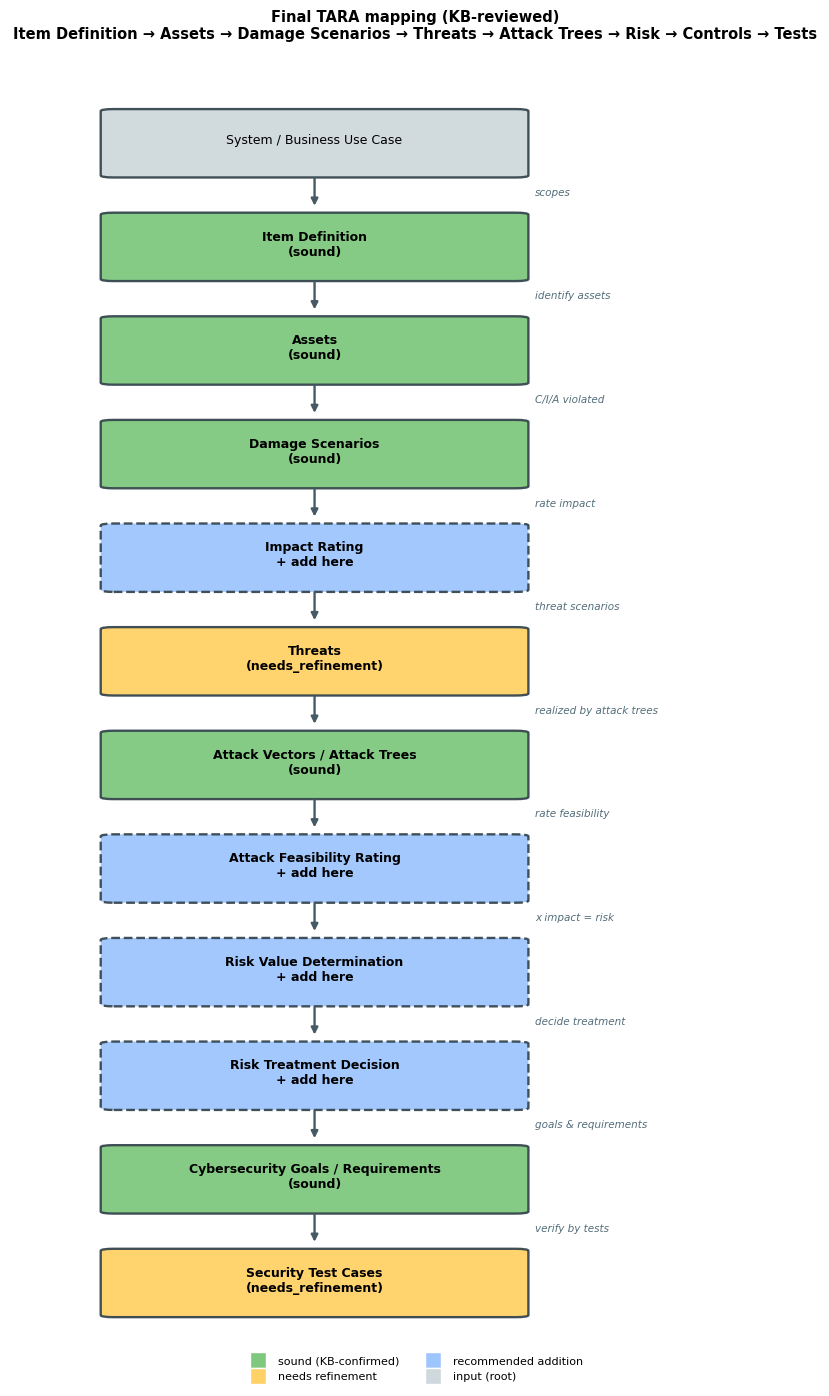

Mapping: System / Business Use Case -> Item Definition -> Assets -> Damage Scenarios -> Impact Rating -> Threats -> Attack Vectors / Attack Trees -> Attack Feasibility Rating -> Risk Value Determination -> Risk Treatment Decision -> Cybersecurity Goals / Requirements -> Security Test Cases


In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

# verdict for each produced stage (the transition that creates it), from §3
verdict_of = {r["to"]: r["verdict"] for r in results}

# Final KB-reviewed mapping: original stages (matched to a verdict) + the
# recommended insertions from §4 (kind="added"). (label, match_key, kind)
FLOW = [
    ("System / Business Use Case",          None,                                 "root"),
    ("Item Definition",                     "Item Definition",                    "stage"),
    ("Assets",                              "Assets",                             "stage"),
    ("Damage Scenarios",                    "Damage Scenarios",                   "stage"),
    ("Impact Rating",                       None,                                 "added"),
    ("Threats",                             "Threats",                            "stage"),
    ("Attack Vectors / Attack Trees",       "Attack Vectors",                     "stage"),
    ("Attack Feasibility Rating",           None,                                 "added"),
    ("Risk Value Determination",            None,                                 "added"),
    ("Risk Treatment Decision",             None,                                 "added"),
    ("Cybersecurity Goals / Requirements",  "Cybersecurity Goals / Requirements", "stage"),
    ("Security Test Cases",                 "Security Test Cases",                "stage"),
]
EDGE = ["scopes", "identify assets", "C/I/A violated", "rate impact",
        "threat scenarios", "realized by attack trees", "rate feasibility",
        "x impact = risk", "decide treatment", "goals & requirements", "verify by tests"]

CLR = {"sound": "#7ec97e", "needs_refinement": "#ffd166", "misordered": "#f4a261",
       "missing_step": "#e76f51", "root": "#cfd8dc", "added": "#9ec5fe"}

def node_color(match, kind):
    if kind == "root":  return CLR["root"]
    if kind == "added": return CLR["added"]
    return CLR.get(verdict_of.get(match, "sound"), "#7ec97e")

n = len(FLOW)
fig, ax = plt.subplots(figsize=(8.4, 14))
for idx, (label, match, kind) in enumerate(FLOW):
    y = n - idx
    ax.add_patch(FancyBboxPatch((0.16, y - 0.34), 0.62, 0.62, boxstyle="round,pad=0.02",
                 linewidth=1.7, edgecolor="#37474f", facecolor=node_color(match, kind),
                 alpha=0.95, linestyle="--" if kind == "added" else "-"))
    v = verdict_of.get(match)
    sub = f"\n({v})" if (kind == "stage" and v) else ("\n+ add here" if kind == "added" else "")
    ax.text(0.47, y, f"{label}{sub}", ha="center", va="center", fontsize=9,
            fontweight="bold" if kind != "root" else "normal")
    if idx < n - 1:
        ax.annotate("", xy=(0.47, y - 0.66), xytext=(0.47, y - 0.34),
                    arrowprops=dict(arrowstyle="-|>", color="#455a64", lw=1.7))
        ax.text(0.81, y - 0.5, EDGE[idx], ha="left", va="center",
                fontsize=7.5, color="#546e7a", style="italic")

ax.set_xlim(0, 1.25); ax.set_ylim(0.3, n + 0.9); ax.axis("off")
ax.set_title("Final TARA mapping (KB-reviewed)\n"
             "Item Definition → Assets → Damage Scenarios → Threats → Attack Trees → Risk → Controls → Tests",
             fontsize=10.5, fontweight="bold")
legend = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=CLR["sound"], markersize=12, label="sound (KB-confirmed)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=CLR["needs_refinement"], markersize=12, label="needs refinement"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=CLR["added"], markersize=12, label="recommended addition"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=CLR["root"], markersize=12, label="input (root)"),
]
ax.legend(handles=legend, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

print("Mapping:", " -> ".join(f[0] for f in FLOW))


## Notes
- **What this is:** a RAG-grounded *review* — the verdicts cite the threat-modeling
  / ISO 21434 books, but they're LLM-mediated opinion, not a certification. Use as
  a first-pass sanity check, not a formal compliance audit.
- **The likely gaps** the KB tends to flag in this flow map to ISO/SAE 21434
  Clause 15: damage scenarios need an **impact rating** (S/F/O/P), attack paths
  need an **attack-feasibility rating**, and these combine into a **risk value**
  and a **risk-treatment decision** *before* deriving cybersecurity goals →
  requirements → controls. "Attack Vectors → Controls" with no risk step is the
  usual omission.
- **Tuning:** raise `seed_k`/`limit` in `retrieve()` for more evidence per step;
  swap `MODEL` for a stronger judge; or rerank retrieved chunks
  (see `reference_query_rerank.ipynb`) before judging.

In [7]:
stats = {"transitions_reviewed": len(results),
         "verdicts": pd.Series([r["verdict"] for r in results]).value_counts().to_dict()}
print("review summary:", stats)
print("OK — proposed flow validated against the KB step by step.")
driver.close()

review summary: {'transitions_reviewed': 7, 'verdicts': {'sound': 5, 'needs_refinement': 2}}
OK — proposed flow validated against the KB step by step.
